BATTERY CYCLE LIFE PREDICTION USING DELTA Q VARIANCE ANALYSIS

Step 1: Loading and preprocessing battery data...
Processing batch1...


batch1 cells: 100%|██████████| 46/46 [02:33<00:00,  3.33s/it]


Processing batch2...


batch2 cells: 100%|██████████| 48/48 [02:14<00:00,  2.81s/it]


Processing batch3...


...

Fitting primary_test dataset...


primary_test fitting: 100%|██████████| 43/43 [02:50<00:00,  3.97s/it]


Fitting secondary_test dataset...


secondary_test fitting: 100%|██████████| 40/40 [01:59<00:00,  3.00s/it]



Step 5: Creating variance trajectory visualizations...


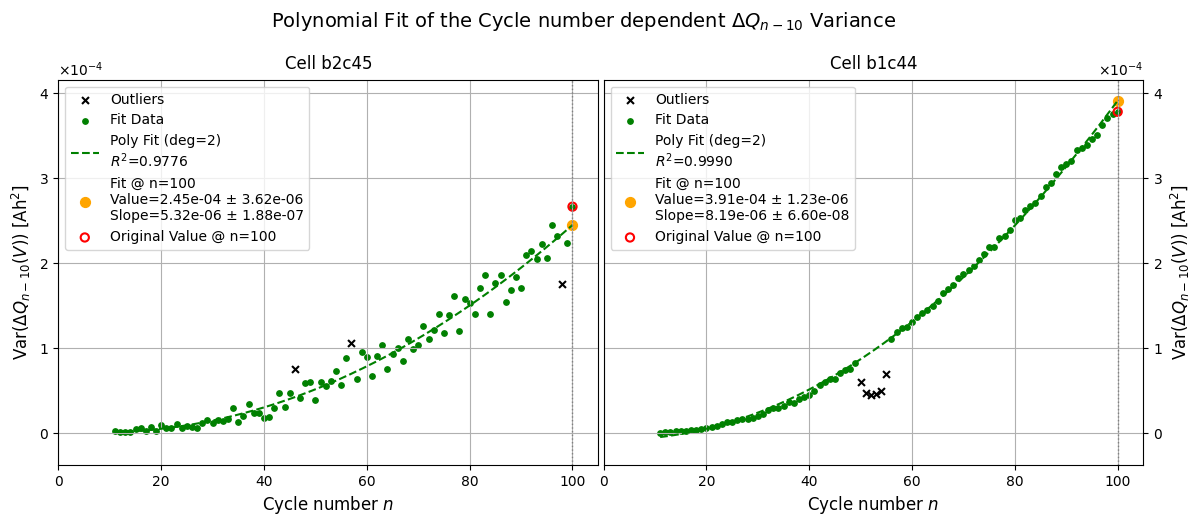


Step 6: Creating cycle life vs. variance feature plots...


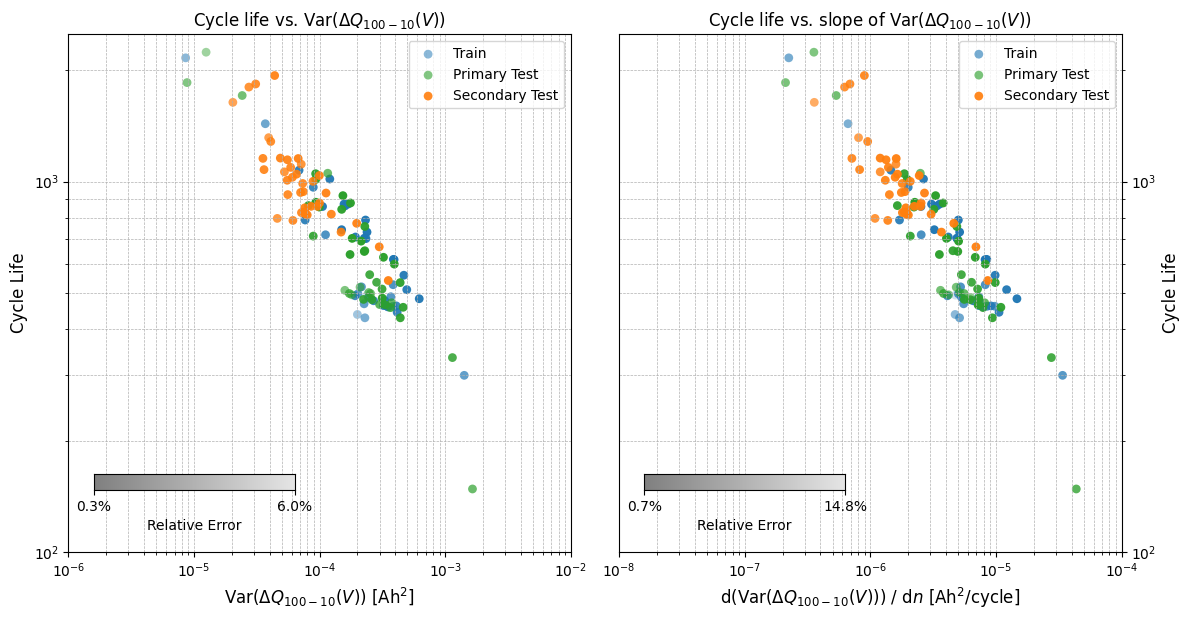


Step 7: Training and evaluating machine learning models...


Training Non-Fit ΔQ Variance: 0epoch [00:00, ?epoch/s]

Non-Fit ΔQ Variance - Training Loss (MAE): 0.1551



Training ΔQ Variance: 0epoch [00:00, ?epoch/s]

ΔQ Variance - Training Loss (MAE): 0.1570



...

ΔQ Variance + Error - Training Loss (MAE): 0.1594



Training ΔQ Variance & Slope + Error: 0epoch [00:00, ?epoch/s]

ΔQ Variance & Slope + Error - Training Loss (MAE): 0.1395

Training Bayesian Error Model (ΔQ Variance):


Output()

Bayesian Error Model (ΔQ Variance) - Training Loss (MAE): 0.1609

Step 8: Creating model performance visualizations...


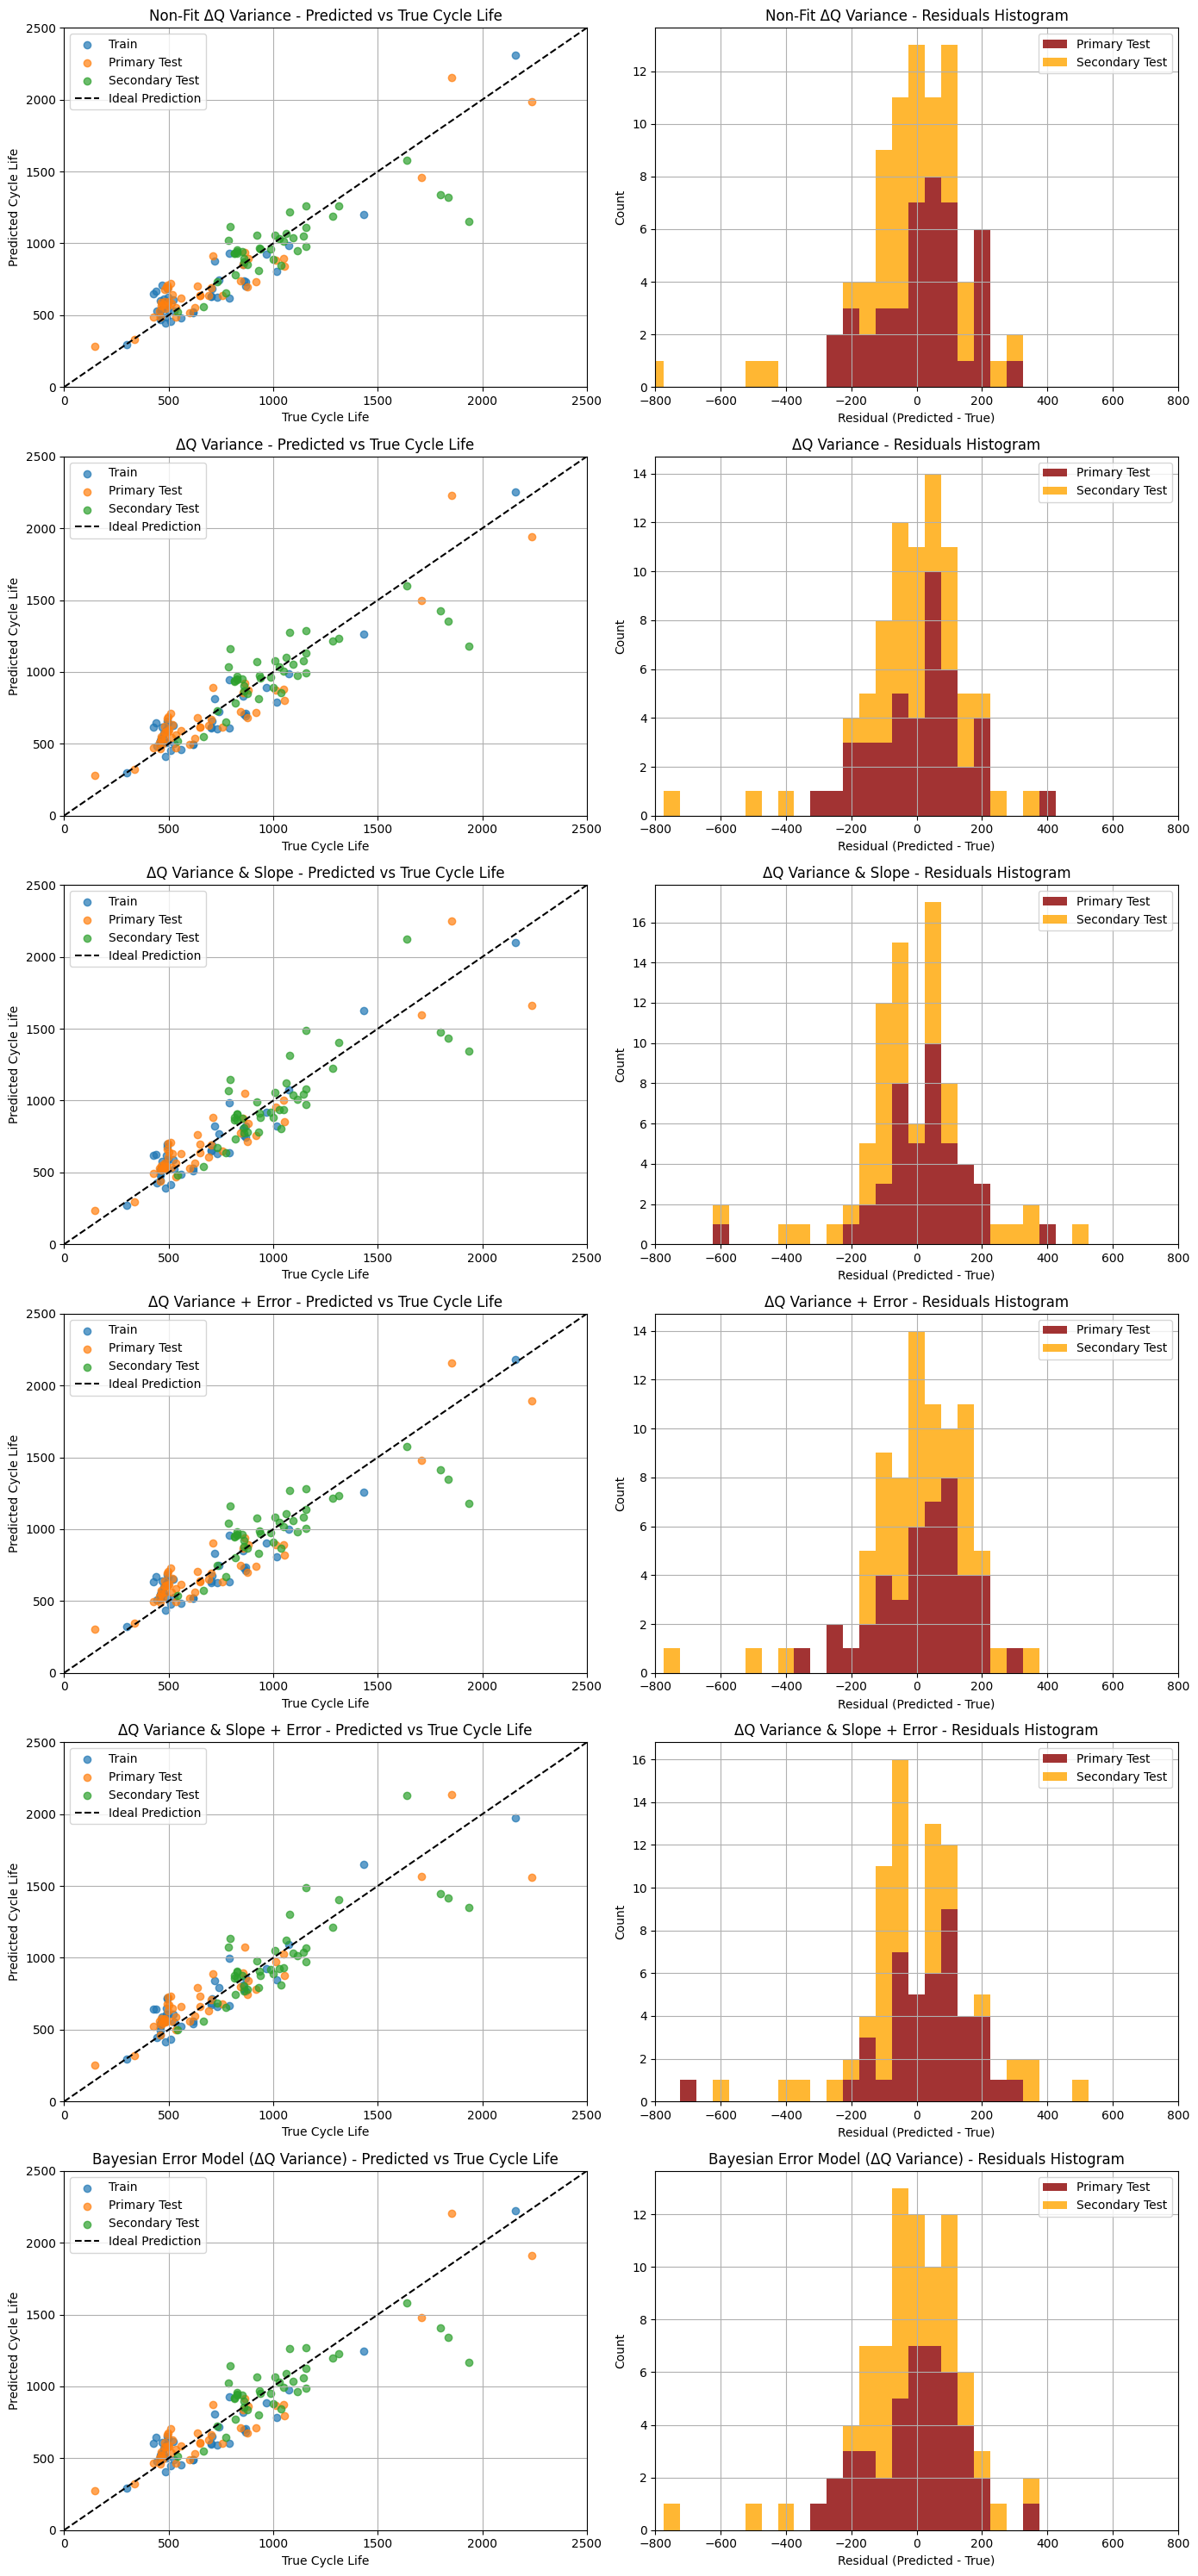


Step 9: Creating model comparison visualization...
Non-Fit ΔQ Variance - Average Percentage Error:
  Primary Test: 18.14%
  Secondary Test: 11.35%

ΔQ Variance - Average Percentage Error:
  Primary Test: 16.50%
  Secondary Test: 11.68%

ΔQ Variance & Slope - Average Percentage Error:
  Primary Test: 15.73%
  Secondary Test: 13.14%

ΔQ Variance + Error - Average Percentage Error:
  Primary Test: 15.65%
  Secondary Test: 12.15%

ΔQ Variance & Slope + Error - Average Percentage Error:
  Primary Test: 15.45%
  Secondary Test: 13.14%

Bayesian Error Model (ΔQ Variance) - Average Percentage Error:
  Primary Test: 16.17%
  Secondary Test: 11.70%



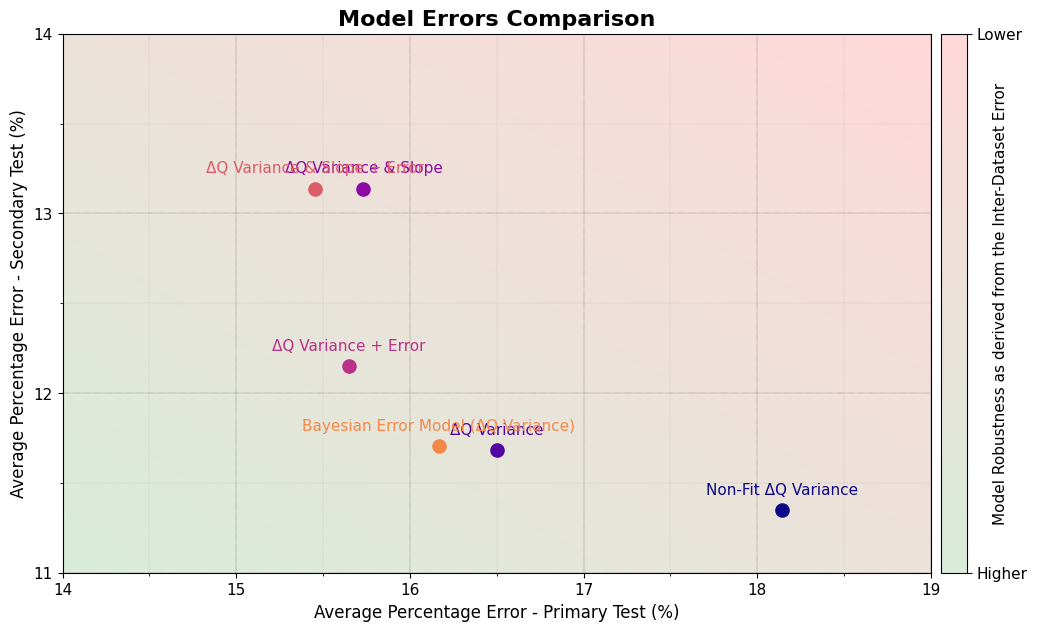

ANALYSIS COMPLETE


In [6]:
"""
Battery Cycle Life Prediction Using Delta Q Variance Analysis

This module implements a comprehensive machine learning pipeline for predicting
battery cycle life using early cycle data. The approach is based on analyzing
variance in discharge curve shapes (Delta Q Variance) as batteries age.

The methodology follows Severson et al.'s work on early prediction of battery
cycle life, implementing feature extraction, polynomial fitting, and multiple
modeling approaches including Bayesian uncertainty quantification.

Key Features:
- Processes battery cycling data from Stanford/MIT dataset
- Extracts Delta Q variance features from discharge curves
- Implements 6 different ML models with uncertainty quantification
- Provides comprehensive visualization and model comparison tools

Usage:
    Run all cells in sequence. The script will:
    1. Download and process battery data (if not cached locally)
    2. Extract Delta Q variance features
    3. Train and evaluate 6 different models
    4. Generate comprehensive visualizations

Requirements:
    - Standard scientific Python stack (numpy, pandas, matplotlib, scipy)
    - TensorFlow/Keras for neural networks
    - PyMC for Bayesian modeling
    - h5py for reading battery data files

Author: Janis Hessling
Date: 20.08.2025
License: MIT License
"""

import os
import urllib.request
import warnings
import logging
from typing import Dict, List, Tuple, Optional, Union

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.interpolate import UnivariateSpline, interp1d, PchipInterpolator
from scipy.signal import medfilt
from numpy.polynomial import Polynomial
from numpy.linalg import LinAlgError
from sklearn.metrics import r2_score

from tqdm import tqdm
from tqdm.keras import TqdmCallback

import tensorflow as tf
from tensorflow.keras import layers

import pymc as pm
import arviz as az

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Configure TensorFlow for cleaner output
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info/warning messages

# =============================================================================
# CONFIGURATION CONSTANTS
# =============================================================================

# Dataset URLs and metadata
BATCH_INFO = [
    {
        'name': 'batch1',
        'url': "https://data.matr.io/1/api/v1/file/5c86c0b5fa2ede00015ddf66/download",
        'filename': "batch1.mat"
    },
    {
        'name': 'batch2',
        'url': "https://data.matr.io/1/api/v1/file/5c86bf13fa2ede00015ddd82/download",
        'filename': "batch2.mat"
    },
    {
        'name': 'batch3',
        'url': "https://data.matr.io/1/api/v1/file/5c86bd64fa2ede00015ddbb2/download",
        'filename': "batch3.mat"
    },
]

# Analysis parameters
REFERENCE_CYCLE = 10  # Reference cycle for Delta Q variance calculation
N_MIN = 1            # Minimum cycle number for analysis
VOLTAGE_MIN = 2.0    # Minimum voltage cutoff (V)
VOLTAGE_MAX = 3.5    # Maximum voltage for analysis (V)
N_VOLTAGE_POINTS = 1000  # Number of interpolation points

# Outlier cells to remove (from Severson et al.)
OUTLIER_CELLS = {
    'batch1': [8, 10, 12, 13, 22],
    'batch2': [],
    'batch3': [2, 23, 32, 37, 42, 43]
}

# Batch merging configuration (continuing cells from batch2 into batch1)
BATCH_MERGE_CONFIG = {
    'batch2_indices': [7, 8, 9, 15, 16],
    'batch1_indices': [0, 1, 2, 3, 4],
    'updated_cycle_lives': [1852, 2160, 2237, 1434, 1709]
}

# =============================================================================
# DATA LOADING AND PREPROCESSING FUNCTIONS
# =============================================================================

def dereference_array_of_refs(ref_array: np.ndarray, file_handle: h5py.File) -> List[np.ndarray]:
    """
    Dereference HDF5 object references to extract actual data arrays.

    Args:
        ref_array: Array of HDF5 object references
        file_handle: Open HDF5 file handle

    Returns:
        List of dereferenced numpy arrays
    """
    return [file_handle[ref][()] for ref in ref_array[:, 0]]


def extract_discharge_segment_fixed_cutoff(
    voltage: np.ndarray,
    capacity: np.ndarray,
    lower_cutoff: float = VOLTAGE_MIN
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Extract discharge segment from voltage/capacity data.

    Identifies the discharge portion of a battery cycle by finding the segment
    from maximum voltage down to the lower cutoff voltage.

    Args:
        voltage: Voltage data array
        capacity: Discharge capacity data array
        lower_cutoff: Lower voltage cutoff for discharge segment

    Returns:
        Tuple of (capacity_segment, voltage_segment) or (None, None) if invalid
    """
    voltage = voltage.ravel()
    capacity = capacity.ravel()

    # Validate input data
    if (len(voltage) == 0 or len(capacity) == 0 or
        not np.isfinite(voltage).any() or not np.isfinite(capacity).any()):
        return None, None

    # Find discharge segment from max voltage to cutoff
    start = np.argmax(voltage)
    if start >= len(voltage):
        return None, None

    end_candidates = np.where(voltage[start:] <= lower_cutoff)[0]
    end = start + end_candidates[0] if len(end_candidates) > 0 else len(voltage) - 1

    if end > start:
        return capacity[start:end+1], voltage[start:end+1]
    else:
        return None, None


def create_uniform_voltage_capacity_df(
    voltage: np.ndarray,
    capacity: np.ndarray,
    n_points: int = N_VOLTAGE_POINTS,
    v_min: float = VOLTAGE_MIN,
    v_max: float = VOLTAGE_MAX
) -> pd.DataFrame:
    """
    Create uniformly spaced voltage-capacity curve using interpolation.

    This function standardizes discharge curves by interpolating to a uniform
    voltage grid, enabling direct comparison between cycles and cells.

    Args:
        voltage: Voltage data points
        capacity: Corresponding capacity data points
        n_points: Number of uniform voltage points for interpolation
        v_min: Minimum voltage for uniform grid
        v_max: Maximum voltage for uniform grid

    Returns:
        DataFrame with columns ['Voltage [V]', 'Discharge Capacity [Ah]']
        Returns NaN-filled DataFrame if interpolation fails
    """
    voltage = voltage.ravel()
    capacity = capacity.ravel()

    # Filter finite values
    mask = np.isfinite(voltage) & np.isfinite(capacity)
    voltage, capacity = voltage[mask], capacity[mask]

    if len(voltage) < 4:
        return pd.DataFrame({
            'Voltage [V]': [np.nan] * n_points,
            'Discharge Capacity [Ah]': [np.nan] * n_points
        })

    # Include boundary points if they exist
    above = np.where(voltage > v_max)[0]
    below = np.where(voltage < v_min)[0]

    if above.size:
        mask[above[np.argmin(voltage[above] - v_max)]] = True
    if below.size:
        mask[below[np.argmin(v_min - voltage[below])]] = True

    voltage, capacity = voltage[mask], capacity[mask]

    if len(voltage) < 4:
        return pd.DataFrame({
            'Voltage [V]': [np.nan] * n_points,
            'Discharge Capacity [Ah]': [np.nan] * n_points
        })

    # Sort by voltage for interpolation
    sort_idx = np.argsort(voltage)
    voltage, capacity = voltage[sort_idx], capacity[sort_idx]

    # Smooth spikes using median filter
    def clean_spikes(y: np.ndarray, kernel_size: int = 3) -> np.ndarray:
        """Apply median filter to remove spikes."""
        if len(y) < kernel_size:
            return y
        return medfilt(y, kernel_size=kernel_size)

    capacity = clean_spikes(capacity)
    voltage_uniform = np.linspace(v_max, v_min, n_points)

    # Try multiple interpolation methods in order of preference
    try:
        # Primary: Univariate spline with smoothing
        spline = UnivariateSpline(voltage, capacity, s=5e-5)
        capacity_uniform = spline(voltage_uniform)
        if not np.isfinite(capacity_uniform).all():
            raise Exception("Spline interpolation produced non-finite values")
    except:
        try:
            # Fallback 1: PCHIP interpolation
            capacity_uniform = PchipInterpolator(voltage, capacity)(voltage_uniform)
        except:
            # Fallback 2: Linear interpolation with extrapolation
            capacity_uniform = interp1d(
                voltage, capacity,
                kind='linear',
                bounds_error=False,
                fill_value='extrapolate'
            )(voltage_uniform)

    # Final validation
    if not np.isfinite(capacity_uniform).all():
        return pd.DataFrame({
            'Voltage [V]': [np.nan] * n_points,
            'Discharge Capacity [Ah]': [np.nan] * n_points
        })

    return pd.DataFrame({
        'Voltage [V]': voltage_uniform[::-1],
        'Discharge Capacity [Ah]': capacity_uniform[::-1]
    })


def load_and_process_battery_data(batch_info: List[Dict]) -> Tuple[List[Dict], Dict[str, List[Dict]]]:
    """
    Load and process battery data from all batches.

    Downloads data files if not present locally, then processes each batch
    to extract cycle data for all cells.

    Args:
        batch_info: List of dictionaries containing batch metadata

    Returns:
        Tuple of (cell_data_list, batch_map_dict)
        cell_data_list: List of all processed cell records
        batch_map_dict: Dictionary mapping batch names to cell lists
    """
    cell_data = []
    batch_map = {}

    for batch in batch_info:
        print(f"Processing {batch['name']}...")

        # Download data file if not present
        if not os.path.exists(batch['filename']):
            print(f"Downloading {batch['filename']}...")
            urllib.request.urlretrieve(batch['url'], batch['filename'])

        # Process batch data
        with h5py.File(batch['filename'], 'r') as f:
            # Extract cycle life information
            cycle_life_refs = f['batch']['cycle_life']
            cycle_lives = [
                int(f[ref][()][0][0]) if not np.isnan(f[ref][()][0][0]) else np.nan
                for ref in cycle_life_refs[:, 0]
            ]

            # Extract cycle data
            cycles = f['batch']['cycles']

            # Process each cell in the batch
            for i in tqdm(range(cycles.shape[0]), desc=f"{batch['name']} cells"):
                try:
                    cell = f[cycles[i, 0]]

                    # Dereference voltage and capacity arrays
                    V_list = dereference_array_of_refs(cell['V'], f)
                    Qd_list = dereference_array_of_refs(cell['Qd'], f)
                    n_cycles = min(len(V_list), len(Qd_list))

                    # Process all cycles for this cell
                    all_cycles = {}
                    for c in range(n_cycles):
                        q, v = Qd_list[c], V_list[c]
                        q_seg, v_seg = extract_discharge_segment_fixed_cutoff(v, q)

                        if q_seg is not None:
                            df_interp = create_uniform_voltage_capacity_df(v_seg, q_seg)
                        else:
                            df_interp = None

                        all_cycles[c] = df_interp

                    # Create cell record
                    entry = {
                        'batch': batch['name'],
                        'cell_index': i,
                        'cycle_life': cycle_lives[i],
                        'all_cycles': all_cycles
                    }

                    cell_data.append(entry)
                    batch_map.setdefault(batch['name'], []).append(entry)

                except Exception as e:
                    print(f"Error processing cell {i} in {batch['name']}: {e}")

    return cell_data, batch_map


def merge_batch_data(batch_map: Dict[str, List[Dict]]) -> Dict[str, List[Dict]]:
    """
    Merge overlapping cells from batch2 into batch1.

    Some cells were continued from batch1 to batch2. This function combines
    their cycle data and updates the final cycle life.

    Args:
        batch_map: Dictionary mapping batch names to cell lists

    Returns:
        Updated batch_map with merged data
    """
    b2_ids = BATCH_MERGE_CONFIG['batch2_indices']
    b1_ids = BATCH_MERGE_CONFIG['batch1_indices']
    updated_cycle_lives = BATCH_MERGE_CONFIG['updated_cycle_lives']

    for b1_idx, b2_idx, new_life in zip(b1_ids, b2_ids, updated_cycle_lives):
        b1_cell = batch_map['batch1'][b1_idx]
        b2_cell = batch_map['batch2'][b2_idx]

        # Calculate offset for batch2 cycles
        offset = max(b1_cell['all_cycles'].keys()) + 1

        # Merge batch2 cycles into batch1 cell
        for c_idx, df in b2_cell['all_cycles'].items():
            b1_cell['all_cycles'][c_idx + offset] = df

        # Update cycle life
        b1_cell['cycle_life'] = new_life

        # Mark batch2 cell as merged
        batch_map['batch2'][b2_idx] = None

    return batch_map


def clean_and_split_data(batch_map: Dict[str, List[Dict]]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Clean outlier cells and split data into train/test sets.

    Removes outlier cells identified in literature, handles problematic cycles,
    and creates train/test splits following the original methodology.

    Args:
        batch_map: Dictionary mapping batch names to cell lists

    Returns:
        Tuple of (train_df, primary_test_df, secondary_test_df)
    """
    # Collect valid cells
    valid_cells = []
    for batch_cells in batch_map.values():
        for cell in batch_cells:
            if (isinstance(cell, dict) and cell is not None and
                all(k in cell for k in ['batch', 'cell_index', 'cycle_life', 'all_cycles'])):
                valid_cells.append(cell)

    df_all = pd.DataFrame(valid_cells)

    # Remove outlier cells
    for batch, idxs in OUTLIER_CELLS.items():
        df_all = df_all[~((df_all['batch'] == batch) & (df_all['cell_index'].isin(idxs)))]

    df_all = df_all.reset_index(drop=True)

    # Remove specific faulty cycles for batch1 cell 18
    for idx, row in df_all.iterrows():
        if row['batch'] == 'batch1' and row['cell_index'] == 18:
            cycles = row['all_cycles']
            # Remove cycles 49-52 and 30-39 (identified as faulty)
            cycles_to_drop = list(range(49, 53)) + list(range(30, 40))
            for c in cycles_to_drop:
                if c in cycles:
                    del cycles[c]

    # Create train/test split
    def split_indices(df: pd.DataFrame, batch_name: str) -> Tuple[List[int], List[int]]:
        """Split batch indices using alternating pattern."""
        b = df[df['batch'] == batch_name].reset_index()
        total = len(b)
        even = [i for i in range(0, total - 2) if i % 2 == 0]
        odd = [i for i in range(0, total - 2) if i % 2 == 1]
        return even, odd + [total - 2, total - 1]

    # Separate batches
    batch1 = df_all[df_all['batch'] == 'batch1'].reset_index(drop=True)
    batch2 = df_all[df_all['batch'] == 'batch2'].reset_index(drop=True)
    batch3 = df_all[df_all['batch'] == 'batch3'].reset_index(drop=True)

    # Create train/test splits
    train = pd.concat([
        batch1.iloc[1::2],  # Odd indices from batch1
        batch2.iloc[split_indices(df_all, 'batch2')[0]]  # Even indices from batch2
    ]).reset_index(drop=True)

    primary_test = pd.concat([
        batch1.iloc[0::2],  # Even indices from batch1
        batch2.iloc[split_indices(df_all, 'batch2')[1]]  # Odd + last 2 from batch2
    ]).reset_index(drop=True)

    secondary_test = batch3.copy().reset_index(drop=True)  # All of batch3

    return train, primary_test, secondary_test

# =============================================================================
# DELTA Q VARIANCE FEATURE EXTRACTION
# =============================================================================

def compute_delta_q_variances_dynamic(
    cell_data_dict: Dict[int, pd.DataFrame],
    ref_cycle: int = REFERENCE_CYCLE,
    n_min: int = N_MIN
) -> Dict[str, float]:
    """
    Compute Delta Q variance features for a single cell.

    For each cycle n, computes the variance of the difference between the
    discharge capacity curve at cycle n and the reference cycle.

    Args:
        cell_data_dict: Dictionary mapping cycle numbers to DataFrames
        ref_cycle: Reference cycle number for comparison
        n_min: Minimum cycle number to process

    Returns:
        Dictionary mapping feature names to variance values
    """
    result = {}

    # Validate reference cycle
    if (ref_cycle not in cell_data_dict or
        cell_data_dict[ref_cycle] is None or
        cell_data_dict[ref_cycle].isna().values.any()):
        # If reference cycle is invalid, return NaN for all features
        for n in cell_data_dict.keys():
            if n >= n_min:
                result[f'delta_q_variance_{n}_{ref_cycle}'] = np.nan
        return result

    # Extract reference capacity curve
    q_ref = cell_data_dict[ref_cycle]['Discharge Capacity [Ah]'].values
    max_cycle = max(cell_data_dict.keys())

    # Compute variance for each cycle
    for n in range(n_min, max_cycle + 1):
        key = f'delta_q_variance_{n}_{ref_cycle}'

        if (n not in cell_data_dict or
            cell_data_dict[n] is None or
            cell_data_dict[n].isna().values.any()):
            result[key] = np.nan
        elif n == ref_cycle:
            result[key] = 0.0  # No difference from itself
        else:
            q_n = cell_data_dict[n]['Discharge Capacity [Ah]'].values
            delta_q = q_n - q_ref
            result[key] = np.var(delta_q)

    return result


def build_delta_q_variance_df_dynamic(
    dataset: pd.DataFrame,
    ref_cycle: int = REFERENCE_CYCLE,
    n_min: int = N_MIN
) -> pd.DataFrame:
    """
    Build Delta Q variance feature DataFrame for entire dataset.

    Processes all cells in the dataset to create a feature matrix where
    each row represents a cell and columns are Delta Q variance features.

    Args:
        dataset: DataFrame containing cell data
        ref_cycle: Reference cycle number for variance computation
        n_min: Minimum cycle number to process

    Returns:
        DataFrame with Delta Q variance features for each cell
    """
    records = []

    for _, row in dataset.iterrows():
        batch_name = row['batch']
        cell_index = row['cell_index']

        # Create standardized cell label (e.g., 'b1c5' for batch1, cell5)
        batch_num = batch_name[-1]
        cell_label = f"b{batch_num}c{cell_index}"

        cycle_life = row['cycle_life']
        cell_data = row['all_cycles']

        # Create base record
        record = {
            'cell_index': cell_label,
            'cycle_life': cycle_life
        }

        # Add Delta Q variance features
        delta_q_dict = compute_delta_q_variances_dynamic(cell_data, ref_cycle, n_min)
        record.update(delta_q_dict)
        records.append(record)

    return pd.DataFrame(records)

# =============================================================================
# DATA CLEANING AND SPIKE REMOVAL
# =============================================================================

def remove_spikes_relative_diff(y: np.ndarray, factor: float = 10.0) -> np.ndarray:
    """
    Remove spikes from time series using relative difference criterion.

    A point is considered a spike if it differs from both neighbors by more
    than 'factor' times the typical neighboring differences.

    Args:
        y: Input array
        factor: Threshold factor for spike detection

    Returns:
        Array with spikes replaced by NaN
    """
    y = np.array(y, dtype=np.float64)
    cleaned = y.copy()

    # Need at least 7 points to check spikes (3 points on each side)
    for i in range(3, len(y) - 3):
        # Current point differences to neighbors
        diff_prev = abs(y[i] - y[i-1])
        diff_next = abs(y[i] - y[i+1])

        # Typical neighboring differences
        diff_prev_prev = (abs(y[i-1] - y[i-2]) + abs(y[i-2] - y[i-3])) / 2
        diff_next_next = (abs(y[i+1] - y[i+2]) + abs(y[i+2] - y[i+3])) / 2

        # Check if current point is a spike
        if (diff_prev > factor * diff_prev_prev and
            diff_next > factor * diff_next_next):
            cleaned[i] = np.nan

    return cleaned


def remove_spikes_from_delta_q_df_relative_diff(
    df: pd.DataFrame,
    factor: float = 10.0
) -> pd.DataFrame:
    """
    Remove spikes from all Delta Q variance columns in DataFrame.

    Args:
        df: DataFrame containing Delta Q variance features
        factor: Threshold factor for spike detection

    Returns:
        DataFrame with spikes removed from variance columns
    """
    cleaned_df = df.copy()
    delta_cols = [col for col in df.columns if col.startswith('delta_q_variance_')]

    for _, row in df.iterrows():
        values = row[delta_cols].values.astype(float)
        cleaned_values = remove_spikes_relative_diff(values, factor=factor)
        cleaned_df.loc[row.name, delta_cols] = cleaned_values

    return cleaned_df

# =============================================================================
# POLYNOMIAL FITTING AND FEATURE EXTRACTION
# =============================================================================

def extract_cell_data(
    df: pd.DataFrame,
    cell_index: str,
    n_min: int = 11,
    n_max: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract cycle numbers and variance values for a specific cell.

    Args:
        df: DataFrame containing Delta Q variance features
        cell_index: Cell identifier (e.g., 'b1c5')
        n_min: Minimum cycle number to extract
        n_max: Maximum cycle number to extract

    Returns:
        Tuple of (cycle_numbers, variance_values)
    """
    row = df[df['cell_index'] == cell_index]
    if len(row) == 0:
        return np.array([]), np.array([])

    x, y = [], []
    for col in df.columns:
        if col.startswith('delta_q_variance_'):
            try:
                n = int(col.split('_')[3])  # Extract cycle number from column name
                val = row.iloc[0][col]
                if n_min <= n <= n_max and not pd.isna(val):
                    x.append(n)
                    y.append(val)
            except (IndexError, ValueError):
                continue  # Skip malformed column names

    return np.array(x), np.array(y)


def process_single_dataset(
    delta_q_df: pd.DataFrame,
    dataset_name: str = "dataset",
    factor: float = 10.0,
    poly_degree: int = 2,
    n_eval: int = 100
) -> pd.DataFrame:
    """
    Process a single dataset to extract polynomial fit features.

    For each cell, fits a polynomial to the Delta Q variance trajectory,
    removes outliers iteratively, and extracts features at the evaluation point.

    Args:
        delta_q_df: DataFrame with Delta Q variance features
        dataset_name: Name of dataset for logging
        factor: Spike removal threshold factor
        poly_degree: Degree of polynomial for fitting
        n_eval: Cycle number at which to evaluate fitted polynomial

    Returns:
        DataFrame with extracted features for each cell
    """
    print(f"Fitting {dataset_name} dataset...")

    # Remove spikes from data
    delta_q_clean = remove_spikes_from_delta_q_df_relative_diff(delta_q_df, factor=factor)
    results = []

    cell_indices = delta_q_df['cell_index'].unique()

    for cell_index in tqdm(cell_indices, desc=f"{dataset_name} fitting"):
        # Extract data for this cell
        x_orig, y_orig = extract_cell_data(delta_q_df, cell_index)
        x_clean, y_clean = extract_cell_data(delta_q_clean, cell_index)

        if len(x_clean) < 5:  # Need minimum points for fitting
            continue

        x_fit, y_fit = x_clean, y_clean
        mask_inliers = np.ones_like(y_clean, dtype=bool)

        try:
            # Iterative outlier removal (3 iterations)
            for iteration in range(3):
                # Fit polynomial to current inliers
                p = Polynomial.fit(x_fit[mask_inliers], y_fit[mask_inliers], deg=poly_degree)
                y_pred = p(x_fit[mask_inliers])

                # Identify outliers using 4-sigma criterion
                residuals = np.abs(y_fit[mask_inliers] - y_pred)
                std_dev = np.std(residuals)
                new_mask = residuals < 4 * std_dev

                # Update global mask
                temp_mask = np.zeros_like(mask_inliers)
                temp_mask[np.where(mask_inliers)[0][new_mask]] = True
                mask_inliers = temp_mask

            # Final polynomial fit with covariance estimation
            x_final = x_fit[mask_inliers]
            y_final = y_fit[mask_inliers]

            if len(x_final) < 3:  # Need minimum points for covariance
                continue

            coeffs, cov = np.polyfit(x_final, y_final, deg=poly_degree, cov=True)
            p_final = np.poly1d(coeffs)

            # Evaluate polynomial and its derivative at n_eval
            y_eval = p_final(n_eval)
            slope_eval = np.polyder(p_final)(n_eval)

            # Estimate uncertainties using error propagation
            # For polynomial a*x^2 + b*x + c evaluated at x=n_eval
            J_val = np.array([n_eval**2, n_eval, 1])  # Jacobian for value
            err_y = np.sqrt(J_val @ cov @ J_val.T)

            # For derivative 2*a*x + b evaluated at x=n_eval
            J_slope = np.array([2 * n_eval, 1, 0])  # Jacobian for slope
            err_slope = np.sqrt(J_slope @ cov @ J_slope.T)

            # Store results
            results.append({
                'cell_index': cell_index,
                'cycle_life': delta_q_df.loc[delta_q_df['cell_index'] == cell_index, 'cycle_life'].iloc[0],
                'delta_q_variance': y_eval,
                'delta_q_variance_error': err_y,
                'd_delta_q_variance_dn': slope_eval,
                'd_delta_q_variance_dn_error': err_slope
            })

        except (LinAlgError, Exception) as e:
            print(f"[{dataset_name}] Cell {cell_index}: Fit failed - {e}")
            continue

    return pd.DataFrame(results)


def process_multiple_datasets(
    datasets: Dict[str, pd.DataFrame],
    factor: float = 10.0,
    poly_degree: int = 2,
    n_eval: int = 100
) -> Dict[str, pd.DataFrame]:
    """
    Process multiple datasets to extract polynomial fit features.

    Args:
        datasets: Dictionary mapping dataset names to DataFrames
        factor: Spike removal threshold factor
        poly_degree: Degree of polynomial for fitting
        n_eval: Cycle number at which to evaluate fitted polynomial

    Returns:
        Dictionary mapping dataset names to processed DataFrames
    """
    return {
        name: process_single_dataset(
            df,
            dataset_name=name,
            factor=factor,
            poly_degree=poly_degree,
            n_eval=n_eval
        )
        for name, df in datasets.items()
    }

# =============================================================================
# MACHINE LEARNING MODELS AND UTILITIES
# =============================================================================

def compute_weights_from_error(
    err_array: np.ndarray,
    min_weight: float = 0.1,
    max_weight: float = 10.0,
    eps: float = 1e-9
) -> np.ndarray:
    """
    Compute sample weights based on prediction uncertainties.

    Higher uncertainty measurements receive lower weights during training.
    Uses squared log-normalized errors to emphasize the difference between
    high and low uncertainty measurements.

    Args:
        err_array: Array of error/uncertainty values
        min_weight: Minimum allowed weight
        max_weight: Maximum allowed weight
        eps: Small value to prevent log(0)

    Returns:
        Array of normalized sample weights
    """
    # Handle NaN/infinite values
    err_clean = np.nan_to_num(
        err_array,
        nan=np.nanmedian(err_array),
        posinf=np.nanmedian(err_array),
        neginf=np.nanmedian(err_array)
    )

    # Log-transform errors for better dynamic range
    log_err = np.log(err_clean + eps)
    lo, hi = log_err.min(), log_err.max()

    if hi <= lo:
        norm_log_err = np.zeros_like(log_err)
    else:
        norm_log_err = (log_err - lo) / (hi - lo)

    # Convert to weights: lower error -> higher weight
    weights = 1.0 - (norm_log_err)**2
    weights = np.clip(weights, a_min=min_weight, a_max=max_weight)

    # Normalize to maintain same total training influence
    weights = weights * (len(weights) / np.sum(weights))

    return weights


def train_and_evaluate_model(
    train_df: pd.DataFrame,
    primary_test_df: pd.DataFrame,
    secondary_test_df: pd.DataFrame,
    feature_cols: Union[str, List[str]],
    label_col: str = 'cycle_life',
    model_name: str = 'Model',
    sample_weight_train: Optional[np.ndarray] = None
) -> Dict:
    """
    Train and evaluate a linear regression model with log-transformed features.

    Uses TensorFlow/Keras to implement a simple linear model with normalization.
    All features and targets are log-transformed for better linearity.

    Args:
        train_df: Training dataset
        primary_test_df: Primary test dataset
        secondary_test_df: Secondary test dataset
        feature_cols: Column name(s) to use as features
        label_col: Column name for target variable
        model_name: Name for logging and results
        sample_weight_train: Optional sample weights for training

    Returns:
        Dictionary containing predictions, true values, and residuals
    """
    # Prepare features (log transform for better linearity)
    if isinstance(feature_cols, str):
        train_features = np.log(train_df[feature_cols].values).reshape(-1, 1)
        primary_features = np.log(primary_test_df[feature_cols].values).reshape(-1, 1)
        secondary_features = np.log(secondary_test_df[feature_cols].values).reshape(-1, 1)
    else:
        train_features = np.log(train_df[feature_cols].values)
        primary_features = np.log(primary_test_df[feature_cols].values)
        secondary_features = np.log(secondary_test_df[feature_cols].values)

    # Prepare labels (log transform)
    train_labels = np.log(train_df[label_col].values).reshape(-1, 1)
    primary_labels = np.log(primary_test_df[label_col].values).reshape(-1, 1)
    secondary_labels = np.log(secondary_test_df[label_col].values).reshape(-1, 1)

    # Feature normalization based on training set statistics
    normalizer = layers.Normalization(axis=-1)
    normalizer.adapt(train_features)

    # Define simple linear model
    model = tf.keras.Sequential([
        normalizer,
        layers.Dense(units=1)  # Linear regression in log-space
    ])

    # Compile with Adam optimizer and MAE loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='mean_absolute_error'
    )

    # Train model with optional sample weighting
    training_kwargs = {
        'x': train_features,
        'y': train_labels,
        'epochs': 2000,
        'verbose': 0,
        'callbacks': [TqdmCallback(verbose=0, desc=f"Training {model_name}", leave=True)]
    }

    if sample_weight_train is not None:
        training_kwargs['sample_weight'] = sample_weight_train

    model.fit(**training_kwargs)

    # Evaluate training performance
    train_loss = model.evaluate(train_features, train_labels, verbose=0)
    print(f"{model_name} - Training Loss (MAE): {train_loss:.4f}")
    print()

    # Helper function for predictions (convert back from log-space)
    def predict_exp(features: np.ndarray) -> np.ndarray:
        """Make predictions and convert back to original scale."""
        # Ensure consistent tensor shape and type
        features = tf.convert_to_tensor(features, dtype=tf.float32)
        preds_log = model(features, training=False).numpy().flatten()
        return np.exp(preds_log)

    # Generate predictions for all datasets
    train_preds = predict_exp(train_features)
    primary_preds = predict_exp(primary_features)
    secondary_preds = predict_exp(secondary_features)

    # Convert true labels back from log-space
    train_true = np.exp(train_labels).flatten()
    primary_true = np.exp(primary_labels).flatten()
    secondary_true = np.exp(secondary_labels).flatten()

    # Compute residuals for test sets
    primary_residuals = primary_preds - primary_true
    secondary_residuals = secondary_preds - secondary_true

    return {
        'train_preds': train_preds,
        'primary_preds': primary_preds,
        'secondary_preds': secondary_preds,
        'train_true': train_true,
        'primary_true': primary_true,
        'secondary_true': secondary_true,
        'primary_residuals': primary_residuals,
        'secondary_residuals': secondary_residuals,
        'model_name': model_name
    }


def prepare_data_for_bayesian(
    df: pd.DataFrame,
    feature_col: str = 'delta_q_variance',
    label_col: str = 'cycle_life',
    error_col: str = 'delta_q_variance_error'
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Prepare data for Bayesian modeling with uncertainty propagation.

    Args:
        df: Input DataFrame
        feature_col: Name of feature column
        label_col: Name of target column
        error_col: Name of error/uncertainty column

    Returns:
        Tuple of (log_features, log_targets, feature_errors)
    """
    x = np.log(df[feature_col].values).flatten()
    y = np.log(df[label_col].values).flatten()
    sigma_x = df[error_col].values.astype(float)

    # Handle missing/invalid errors
    sigma_x = np.nan_to_num(sigma_x, nan=np.nanmedian(sigma_x))
    sigma_x = np.clip(sigma_x, 1e-9, None)  # Ensure no zero errors

    return x, y, sigma_x


def train_bayesian_model(
    train_df: pd.DataFrame,
    primary_test_df: pd.DataFrame,
    secondary_test_df: pd.DataFrame,
    feature_col: str = 'delta_q_variance',
    label_col: str = 'cycle_life',
    error_col: str = 'delta_q_variance_error',
    sigma_y: float = 0.1,
    samples: int = 2000,
    tune: int = 1000
) -> Dict:
    """
    Train Bayesian linear regression model with measurement error propagation.

    This model explicitly accounts for uncertainty in the input features,
    propagating this uncertainty through to the final predictions.

    Args:
        train_df: Training dataset
        primary_test_df: Primary test dataset
        secondary_test_df: Secondary test dataset
        feature_col: Name of feature column
        label_col: Name of target column
        error_col: Name of error column for feature uncertainty
        sigma_y: Assumed noise level in target variable
        samples: Number of MCMC samples to draw
        tune: Number of tuning steps for MCMC

    Returns:
        Dictionary containing predictions, true values, residuals, and MCMC trace
    """
    print('Training Bayesian Error Model (ΔQ Variance):')

    # Prepare data for all datasets
    x_train, y_train, sigma_x_train = prepare_data_for_bayesian(
        train_df, feature_col, label_col, error_col
    )
    x_primary_test = np.log(primary_test_df[feature_col].values).flatten()
    y_primary_test = np.log(primary_test_df[label_col].values).flatten()
    x_secondary_test = np.log(secondary_test_df[feature_col].values).flatten()
    y_secondary_test = np.log(secondary_test_df[label_col].values).flatten()

    # Define Bayesian model with measurement error
    with pm.Model() as model:
        # Priors for regression coefficients
        alpha = pm.Normal("alpha", mu=0, sigma=10)  # Intercept
        beta = pm.Normal("beta", mu=0, sigma=10)   # Slope
        sigma = pm.HalfNormal("sigma", sigma=1)    # Residual noise

        # True (unobserved) feature values with measurement error
        x_true = pm.Normal("x_true", mu=x_train, sigma=sigma_x_train, shape=len(x_train))

        # Linear model in log-space
        mu = alpha + beta * x_true

        # Likelihood with combined noise (model + measurement)
        total_sigma = np.sqrt(sigma**2 + sigma_y**2)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=total_sigma, observed=y_train)

        # Sample from posterior
        trace = pm.sample(samples, tune=tune, target_accept=0.9, return_inferencedata=True)

    def posterior_predictive(x_new: np.ndarray, trace, nsamples: int = 2000) -> np.ndarray:
        """Generate posterior predictive samples for new data."""
        # Extract posterior samples
        alpha_samples = trace.posterior["alpha"].stack(draws=("chain", "draw")).values
        beta_samples = trace.posterior["beta"].stack(draws=("chain", "draw")).values
        sigma_samples = trace.posterior["sigma"].stack(draws=("chain", "draw")).values

        # Generate predictions for each posterior sample
        preds = np.zeros((nsamples, len(x_new)))
        for i in range(nsamples):
            a = alpha_samples[i]
            b = beta_samples[i]
            s = sigma_samples[i]
            mu_pred = a + b * x_new
            preds[i, :] = np.random.normal(mu_pred, s)

        return preds

    # Generate posterior predictions
    train_preds_samples = posterior_predictive(x_train, trace)
    primary_preds_samples = posterior_predictive(x_primary_test, trace)
    secondary_preds_samples = posterior_predictive(x_secondary_test, trace)

    # Convert predictions back from log-space (using posterior means)
    train_preds = np.exp(train_preds_samples.mean(axis=0))
    primary_preds = np.exp(primary_preds_samples.mean(axis=0))
    secondary_preds = np.exp(secondary_preds_samples.mean(axis=0))

    # Convert true values back from log-space
    train_true = np.exp(y_train)
    primary_true = np.exp(y_primary_test)
    secondary_true = np.exp(y_secondary_test)

    # Compute residuals
    primary_residuals = primary_preds - primary_true
    secondary_residuals = secondary_preds - secondary_true

    return {
        'train_preds': train_preds,
        'primary_preds': primary_preds,
        'secondary_preds': secondary_preds,
        'train_true': train_true,
        'primary_true': primary_true,
        'secondary_true': secondary_true,
        'primary_residuals': primary_residuals,
        'secondary_residuals': secondary_residuals,
        'trace': trace,
        'model_name': 'Bayesian Error Model (ΔQ Variance)'
    }

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_cell_variance(
    ax: plt.Axes,
    cell_index: str,
    delta_q_variance_train: pd.DataFrame,
    n_eval: int = 100
) -> None:
    """
    Plot Delta Q variance trajectory and polynomial fit for a single cell.

    Shows the variance evolution over cycles, outlier removal process,
    polynomial fit, and evaluation at the specified cycle number.

    Args:
        ax: Matplotlib axes object
        cell_index: Cell identifier to plot
        delta_q_variance_train: Training dataset with variance features
        n_eval: Cycle number for evaluation point
    """
    # Extract original and cleaned data
    x_orig, y_orig = extract_cell_data(delta_q_variance_train, cell_index)
    x_clean, y_clean = extract_cell_data(
        remove_spikes_from_delta_q_df_relative_diff(delta_q_variance_train),
        cell_index
    )

    if len(x_clean) < 5:
        ax.text(0.5, 0.5, f'Insufficient data for {cell_index}',
                transform=ax.transAxes, ha='center', va='center')
        return

    # Iterative outlier removal (same as in processing)
    mask_inliers = np.ones_like(y_clean, dtype=bool)
    x_fit, y_fit = x_clean, y_clean

    for _ in range(3):
        p = Polynomial.fit(x_fit[mask_inliers], y_fit[mask_inliers], deg=2)
        y_pred = p(x_fit[mask_inliers])
        residuals = np.abs(y_fit[mask_inliers] - y_pred)
        std_dev = np.std(residuals)
        new_mask = residuals < 4 * std_dev
        temp_mask = np.zeros_like(mask_inliers)
        temp_mask[np.where(mask_inliers)[0][new_mask]] = True
        mask_inliers = temp_mask

    # Final fit with covariance
    x_final = x_fit[mask_inliers]
    y_final = y_fit[mask_inliers]

    if len(x_final) < 3:
        ax.text(0.5, 0.5, f'Insufficient inliers for {cell_index}',
                transform=ax.transAxes, ha='center', va='center')
        return

    coeffs, cov = np.polyfit(x_final, y_final, deg=2, cov=True)
    p_final = np.poly1d(coeffs)
    y_fit_final = p_final(x_final)

    # R² calculation
    r2 = r2_score(y_final, y_fit_final)

    # Evaluate at n_eval
    y_100 = p_final(n_eval)
    slope_100 = np.polyder(p_final)(n_eval)

    # Error calculation using error propagation
    J_val = np.array([n_eval**2, n_eval, 1])
    err_y100 = np.sqrt(J_val @ cov @ J_val.T)
    J_slope = np.array([2 * n_eval, 1, 0])
    err_slope100 = np.sqrt(J_slope @ cov @ J_slope.T)

    # Plotting setup
    x_min, x_max = 0, 105
    x_smooth = np.linspace(min(x_final), max(x_final), 300)

    # Determine y-axis limits
    all_x = np.concatenate((x_orig, x_clean))
    all_y = np.concatenate((y_orig, y_clean))
    mask_plot = (all_x >= x_min) & (all_x <= x_max)
    y_min, y_max = np.min(all_y[mask_plot]), np.max(all_y[mask_plot])
    margin = 0.1 * (y_max - y_min)
    y_min -= margin
    y_max += margin

    # Plot data points and fit
    ax.scatter(x_clean[~mask_inliers], y_clean[~mask_inliers],
               s=25, marker='x', color='black', label='Outliers')
    ax.scatter(x_final, y_final, s=15, color='green', label='Fit Data')
    ax.plot(x_smooth, p_final(x_smooth), 'g--',
            label=f'Poly Fit (deg=2)\n$R^2$={r2:.4f}')

    # Evaluation point
    ax.scatter([n_eval], [y_100], color='orange', marker='o', s=50,
               label=f'Fit @ n={n_eval}\nValue={y_100:.2e} ± {err_y100:.2e}\n'
                     f'Slope={slope_100:.2e} ± {err_slope100:.2e}')

    # Highlight original value at n_eval if available
    if n_eval in x_orig:
        y_orig_eval = y_orig[np.where(x_orig == n_eval)][0]
        ax.scatter([n_eval], [y_orig_eval], s=35, facecolors='none',
                   edgecolors='red', linewidths=1.5, marker='o',
                   label='Original Value @ n=100')

    # Formatting
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.axvline(n_eval, color='gray', linestyle=':', linewidth=1)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Cycle number $n$", fontsize=12)
    ax.legend()
    ax.grid(True)


def create_variance_plots(
    delta_q_variance_train: pd.DataFrame,
    cell_indices: List[str] = ['b2c45', 'b1c44']
) -> None:
    """
    Create side-by-side variance trajectory plots for example cells.

    Args:
        delta_q_variance_train: Training dataset with variance features
        cell_indices: List of cell identifiers to plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Left plot
    plot_cell_variance(ax=axes[0], cell_index=cell_indices[0],
                      delta_q_variance_train=delta_q_variance_train)
    axes[0].set_ylabel("Var$(\Delta Q_{n-10}$($V$)) [Ah$^2$]", fontsize=12)
    axes[0].set_title(f"Cell {cell_indices[0]}", fontsize=12, pad=8)

    # Right plot
    plot_cell_variance(ax=axes[1], cell_index=cell_indices[1],
                      delta_q_variance_train=delta_q_variance_train)
    axes[1].set_ylabel("Var$(\Delta Q_{n-10}$($V$)) [Ah$^2$]", fontsize=12)
    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_ticks_position("right")
    axes[1].set_title(f"Cell {cell_indices[1]}", fontsize=12, pad=8)

    # Overall title
    fig.suptitle(
        r"Polynomial Fit of the Cycle number dependent $\Delta Q_{n-10}$ Variance",
        fontsize=14, y=1.02
    )

    fig.subplots_adjust(wspace=0.01, top=0.88)
    plt.show()


def create_feature_quality_plots(
    train_fit: pd.DataFrame,
    primary_test_fit: pd.DataFrame,
    secondary_test_fit: pd.DataFrame
) -> None:
    """
    Create scatter plots showing feature quality with error-based transparency.

    Point transparency indicates fit quality - more transparent points have
    higher uncertainty in their fitted values.

    Args:
        train_fit: Training dataset with fitted features
        primary_test_fit: Primary test dataset with fitted features
        secondary_test_fit: Secondary test dataset with fitted features
    """
    # Calculate relative errors for transparency mapping
    for df in [train_fit, primary_test_fit, secondary_test_fit]:
        df['rel_error_var'] = np.abs(df['delta_q_variance_error'] / df['delta_q_variance'])
        df['rel_error_slope'] = np.abs(df['d_delta_q_variance_dn_error'] / df['d_delta_q_variance_dn'])

    # Find global error ranges for consistent transparency scaling
    all_rel_err_var = np.concatenate([
        train_fit['rel_error_var'].values,
        primary_test_fit['rel_error_var'].values,
        secondary_test_fit['rel_error_var'].values
    ])
    all_rel_err_slope = np.concatenate([
        train_fit['rel_error_slope'].values,
        primary_test_fit['rel_error_slope'].values,
        secondary_test_fit['rel_error_slope'].values
    ])

    min_rel_err_var, max_rel_err_var = np.min(all_rel_err_var), np.max(all_rel_err_var)
    min_rel_err_slope, max_rel_err_slope = np.min(all_rel_err_slope), np.max(all_rel_err_slope)

    def rel_err_to_alpha(rel_err: np.ndarray, min_err: float, max_err: float,
                        min_alpha: float = 0.2, max_alpha: float = 1.0) -> np.ndarray:
        """Map relative error to alpha transparency values."""
        norm_err = (rel_err - min_err) / (max_err - min_err)
        return max_alpha - norm_err * (max_alpha - min_alpha)

    # Compute alpha values for all datasets
    for df in [train_fit, primary_test_fit, secondary_test_fit]:
        df['alpha_var'] = rel_err_to_alpha(df['rel_error_var'], min_rel_err_var, max_rel_err_var)
        df['alpha_slope'] = rel_err_to_alpha(df['rel_error_slope'], min_rel_err_slope, max_rel_err_slope)

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6.3), sharey=True)

    # Left plot: ΔQ variance vs cycle life
    axes[0].scatter(train_fit['delta_q_variance'], train_fit['cycle_life'],
                    color='tab:blue', s=40, edgecolors='none',
                    alpha=train_fit['alpha_var'], label='Train')
    axes[0].scatter(primary_test_fit['delta_q_variance'], primary_test_fit['cycle_life'],
                    color='tab:green', s=40, edgecolors='none',
                    alpha=primary_test_fit['alpha_var'], label='Primary Test')
    axes[0].scatter(secondary_test_fit['delta_q_variance'], secondary_test_fit['cycle_life'],
                    color='tab:orange', s=40, edgecolors='none',
                    alpha=secondary_test_fit['alpha_var'], label='Secondary Test')

    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1e-6, 1e-2)
    axes[0].set_ylim(1e2, 2.5e3)
    axes[0].set_xlabel(r'Var$(\Delta Q_{100-10}$($V$)) [Ah$^2$]', fontsize=12)
    axes[0].set_ylabel('Cycle Life', fontsize=12)
    axes[0].set_title(r'Cycle life vs. Var$(\Delta Q_{100-10}$($V$))', fontsize=12)
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0].legend()

    # Alpha gradient bar for left plot
    cax0 = inset_axes(axes[0], width="40%", height="3%", loc='lower left',
                      bbox_to_anchor=(0.05, 0.12, 1, 1),
                      bbox_transform=axes[0].transAxes, borderpad=0)
    gradient = np.zeros((1, 256, 4))
    gradient[:, :, 0:3] = 0.5
    gradient[:, :, 3] = np.linspace(1.0, 0.2, 256)
    cax0.imshow(gradient, aspect='auto', extent=[0, 1, 0, 1])
    cax0.set_xticks([0, 1])
    cax0.set_xticklabels([f"{min_rel_err_var*100:.1f}%", f"{max_rel_err_var*100:.1f}%"])
    cax0.set_yticks([])
    cax0.set_xlabel("Relative Error")

    # Right plot: slope vs cycle life
    axes[1].scatter(train_fit['d_delta_q_variance_dn'], train_fit['cycle_life'],
                    color='tab:blue', s=40, edgecolors='none',
                    alpha=train_fit['alpha_slope'], label='Train')
    axes[1].scatter(primary_test_fit['d_delta_q_variance_dn'], primary_test_fit['cycle_life'],
                    color='tab:green', s=40, edgecolors='none',
                    alpha=primary_test_fit['alpha_slope'], label='Primary Test')
    axes[1].scatter(secondary_test_fit['d_delta_q_variance_dn'], secondary_test_fit['cycle_life'],
                    color='tab:orange', s=40, edgecolors='none',
                    alpha=secondary_test_fit['alpha_slope'], label='Secondary Test')

    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(1e-8, 1e-4)
    axes[1].set_xlabel(r'd(Var$(\Delta Q_{100-10}$($V$))) / d$n$ [Ah$^2$/cycle]', fontsize=12)
    axes[1].set_ylabel('Cycle Life', fontsize=12)
    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_tick_params(labelright=True)
    axes[1].set_title(r'Cycle life vs. slope of Var$(\Delta Q_{100-10}$($V$))', fontsize=12)
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1].legend()

    # Alpha gradient bar for right plot
    cax1 = inset_axes(axes[1], width="40%", height="3%", loc='lower left',
                      bbox_to_anchor=(0.05, 0.12, 1, 1),
                      bbox_transform=axes[1].transAxes, borderpad=0)
    gradient[:, :, 3] = np.linspace(1.0, 0.2, 256)
    cax1.imshow(gradient, aspect='auto', extent=[0, 1, 0, 1])
    cax1.set_xticks([0, 1])
    cax1.set_xticklabels([f"{min_rel_err_slope*100:.1f}%", f"{max_rel_err_slope*100:.1f}%"])
    cax1.set_yticks([])
    cax1.set_xlabel("Relative Error")

    plt.tight_layout()
    plt.show()


def plot_model_comparison(results_list: List[Dict]) -> None:
    """
    Create comprehensive model comparison plots.

    Shows predicted vs true scatter plots and residual histograms for all models
    in a grid layout for easy comparison.

    Args:
        results_list: List of model result dictionaries
    """
    n_models = len(results_list)
    fig, axs = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

    if n_models == 1:
        axs = axs.reshape(1, -1)

    # Find global residual range for consistent histogram binning
    all_residuals = []
    for res in results_list:
        all_residuals.extend(res['primary_residuals'])
        all_residuals.extend(res['secondary_residuals'])

    max_abs_resid_global = max(abs(r) for r in all_residuals)
    bin_width = 50
    limit = bin_width * np.ceil(max_abs_resid_global / bin_width)
    bins = np.arange(-limit - bin_width/2, limit + bin_width*1.5, bin_width)

    for i, res in enumerate(results_list):
        # Left: Predicted vs True scatter plot
        ax = axs[i, 0]
        ax.scatter(res['train_true'], res['train_preds'], label='Train', alpha=0.7)
        ax.scatter(res['primary_true'], res['primary_preds'], label='Primary Test', alpha=0.7)
        ax.scatter(res['secondary_true'], res['secondary_preds'], label='Secondary Test', alpha=0.7)
        ax.plot([0, 2500], [0, 2500], 'k--', label='Ideal Prediction')
        ax.set_title(f"{res['model_name']} - Predicted vs True Cycle Life")
        ax.set_xlabel('True Cycle Life')
        ax.set_ylabel('Predicted Cycle Life')
        ax.set_xlim(0, 2500)
        ax.set_ylim(0, 2500)
        ax.legend()
        ax.grid(True)

        # Right: Residuals histogram
        ax = axs[i, 1]
        ax.hist([res['primary_residuals'], res['secondary_residuals']],
                bins=bins,
                stacked=True,
                label=['Primary Test', 'Secondary Test'],
                color=['darkred', 'orange'],
                alpha=0.8)
        ax.set_xlim(-limit, limit)
        ax.set_title(f"{res['model_name']} - Residuals Histogram")
        ax.set_xlabel('Residual (Predicted - True)')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


def diagonal_gradient(ax: plt.Axes, x_min: float, x_max: float,
                     y_min: float, y_max: float, alpha: float = 0.15) -> Tuple:
    """
    Create diagonal gradient background for robustness visualization.

    Green indicates better performance (lower error), red indicates worse.

    Args:
        ax: Matplotlib axes object
        x_min, x_max: X-axis limits
        y_min, y_max: Y-axis limits
        alpha: Transparency level

    Returns:
        Tuple of (colormap, alpha_value)
    """
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    diag_value = (xx - x_min) / (x_max - x_min) * 0.5 + \
                 (yy - y_min) / (y_max - y_min) * 0.5
    diag_value = np.clip(diag_value, 0, 1)
    green_red_cmap = LinearSegmentedColormap.from_list("green_red", ["green", "red"])
    ax.imshow(
        diag_value,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap=green_red_cmap,
        alpha=alpha,
        aspect='auto'
    )
    return green_red_cmap, alpha


def plot_model_errors_comparison(results_list: List[Dict],
                                primary_test_fit: pd.DataFrame,
                                secondary_test_fit: pd.DataFrame) -> None:
    """
    Create model robustness comparison plot showing error across datasets.

    Points closer to bottom-left corner indicate better overall performance.
    Background gradient helps visualize relative robustness.

    Args:
        results_list: List of model result dictionaries
        primary_test_fit: Primary test dataset (for error weighting)
        secondary_test_fit: Secondary test dataset (for error weighting)
    """
    # Calculate percentage errors for each model
    primary_errors = []
    secondary_errors = []
    model_names = []

    for res in results_list:
        # Handle error-weighted models differently
        if '+ Error' in res['model_name']:
            if 'Slope' in res['model_name']:
                # Combined variance + slope error weighting
                weights_primary = (
                    compute_weights_from_error(primary_test_fit['delta_q_variance_error'].values.astype(float)) +
                    compute_weights_from_error(primary_test_fit['d_delta_q_variance_dn_error'].values.astype(float))
                ) / 2
                weights_secondary = (
                    compute_weights_from_error(secondary_test_fit['delta_q_variance_error'].values.astype(float)) +
                    compute_weights_from_error(secondary_test_fit['d_delta_q_variance_dn_error'].values.astype(float))
                ) / 2
            else:
                # Variance-only error weighting
                weights_primary = compute_weights_from_error(
                    primary_test_fit['delta_q_variance_error'].values.astype(float)
                )
                weights_secondary = compute_weights_from_error(
                    secondary_test_fit['delta_q_variance_error'].values.astype(float)
                )

            # Weighted average percentage error
            primary_pct_error = np.average(
                np.abs(res['primary_residuals'] / res['primary_true']) * 100,
                weights=weights_primary
            )
            secondary_pct_error = np.average(
                np.abs(res['secondary_residuals'] / res['secondary_true']) * 100,
                weights=weights_secondary
            )
        else:
            # Standard mean percentage error
            primary_pct_error = np.mean(np.abs(res['primary_residuals'] / res['primary_true'])) * 100
            secondary_pct_error = np.mean(np.abs(res['secondary_residuals'] / res['secondary_true'])) * 100

        primary_errors.append(primary_pct_error)
        secondary_errors.append(secondary_pct_error)
        model_names.append(res['model_name'])

        # Print individual model performance
        print(f"{res['model_name']} - Average Percentage Error:")
        print(f"  Primary Test: {primary_pct_error:.2f}%")
        print(f"  Secondary Test: {secondary_pct_error:.2f}%")
        print()

    # Create comparison plot
    fig_height = 7

    # Calculate dynamic plot limits based on data
    x_min_data = min(primary_errors)
    x_max_data = max(primary_errors)
    y_min_data = min(secondary_errors)
    y_max_data = max(secondary_errors)

    # Add margins for annotations
    x_min = int(np.floor(x_min_data + 0.5)) - 1
    x_max = int(np.ceil(x_max_data - 0.5)) + 1
    y_min = int(np.floor(y_min_data + 0.95)) - 1
    y_max = int(np.ceil(y_max_data - 0.82)) + 1

    # Calculate figure width based on aspect ratio
    x_range = x_max - x_min
    y_range = y_max - y_min
    aspect_ratio = y_range / x_range
    fig_width = fig_height / aspect_ratio

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Draw background gradient
    green_red_cmap, alpha = diagonal_gradient(ax, x_min, x_max, y_min, y_max, alpha=0.15)

    # Color points by model index for easy identification
    cmap = cm.plasma
    colors = [cmap(i / 7) for i in range(len(results_list))]

    # Scatter plot with model-specific colors
    for i, (x, y) in enumerate(zip(primary_errors, secondary_errors)):
        ax.scatter(x, y, color=colors[i], label=model_names[i], s=90)

    # Annotate points with model names
    for i, name in enumerate(model_names):
        ax.annotate(name, (primary_errors[i], secondary_errors[i]),
                    textcoords="offset points", xytext=(0, 20),
                    ha='center', va='top',
                    color=colors[i], fontsize=11,
                    clip_on=False)

    # Formatting
    ax.set_xlabel('Average Percentage Error - Primary Test (%)', fontsize=12)
    ax.set_ylabel('Average Percentage Error - Secondary Test (%)', fontsize=12)
    ax.set_title('Model Errors Comparison', fontsize=16, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Grid lines
    x_major_ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    y_major_ticks = np.arange(np.ceil(y_min), np.floor(y_max) + 1, 1)
    ax.set_xticks(x_major_ticks)
    ax.set_yticks(y_major_ticks)

    x_minor_ticks = np.arange(x_min, x_max + 0.5, 0.5)
    y_minor_ticks = np.arange(y_min, y_max + 0.5, 0.5)
    ax.set_xticks(x_minor_ticks, minor=True)
    ax.set_yticks(y_minor_ticks, minor=True)

    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.grid(which='major', color='black', linestyle=':', linewidth=0.3)
    ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.2)

    # Add colorbar for robustness interpretation
    norm = Normalize(vmin=x_min, vmax=x_max)
    colors_with_alpha = green_red_cmap(np.linspace(0, 1, 256))
    colors_with_alpha[:, -1] = alpha
    cmap_with_alpha = LinearSegmentedColormap.from_list("green_red_alpha", colors_with_alpha)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)

    cb = ColorbarBase(cax, cmap=cmap_with_alpha, norm=norm)
    cb.set_ticks([x_min, x_max])
    cb.set_ticklabels(['Higher', 'Lower'], fontsize=11)
    cb.set_label("Model Robustness as derived from the Inter-Dataset Error",
                 labelpad=-25, fontsize=11)

    plt.show()

# =============================================================================
# MAIN EXECUTION PIPELINE
# =============================================================================

def main():
    """
    Main execution pipeline for battery cycle life prediction analysis.

    Runs the complete pipeline from data loading through model comparison,
    generating all necessary plots and performance metrics.
    """
    print("="*80)
    print("BATTERY CYCLE LIFE PREDICTION USING DELTA Q VARIANCE ANALYSIS")
    print("="*80)
    print()

    # Step 1: Load and preprocess battery data
    print("Step 1: Loading and preprocessing battery data...")
    cell_data, batch_map = load_and_process_battery_data(BATCH_INFO)

    # Step 2: Merge batch data and clean outliers
    print("\nStep 2: Merging batches and cleaning data...")
    batch_map = merge_batch_data(batch_map)
    train, primary_test, secondary_test = clean_and_split_data(batch_map)

    print(f"Data split summary:")
    print(f"  Training set: {len(train)} cells")
    print(f"  Primary test set: {len(primary_test)} cells")
    print(f"  Secondary test set: {len(secondary_test)} cells")
    print()

    # Step 3: Extract Delta Q variance features
    print("Step 3: Extracting Delta Q variance features...")
    delta_q_variance_train = build_delta_q_variance_df_dynamic(train)
    delta_q_variance_primary_test = build_delta_q_variance_df_dynamic(primary_test)
    delta_q_variance_secondary_test = build_delta_q_variance_df_dynamic(secondary_test)

    # Step 4: Polynomial fitting and feature extraction
    print("\nStep 4: Polynomial fitting and feature extraction...")
    datasets = {
        "train": delta_q_variance_train,
        "primary_test": delta_q_variance_primary_test,
        "secondary_test": delta_q_variance_secondary_test
    }

    fit_results = process_multiple_datasets(datasets)
    train_fit = fit_results["train"]
    primary_test_fit = fit_results["primary_test"]
    secondary_test_fit = fit_results["secondary_test"]

    # Step 5: Visualization of fitting process
    print("\nStep 5: Creating variance trajectory visualizations...")
    create_variance_plots(delta_q_variance_train)

    # Step 6: Creating cycle life vs. variance feature plots
    print("\nStep 6: Creating cycle life vs. variance feature plots...")
    create_feature_quality_plots(train_fit, primary_test_fit, secondary_test_fit)

    # Step 7: Train and evaluate machine learning models
    print("\nStep 7: Training and evaluating machine learning models...")

    # Model 1: Non-fitted ΔQ variance (baseline)
    results1 = train_and_evaluate_model(
        train_df=delta_q_variance_train,
        primary_test_df=delta_q_variance_primary_test,
        secondary_test_df=delta_q_variance_secondary_test,
        feature_cols='delta_q_variance_100_10',
        label_col='cycle_life',
        model_name='Non-Fit ΔQ Variance'
    )

    # Model 2: Fitted ΔQ variance
    results2 = train_and_evaluate_model(
        train_df=train_fit,
        primary_test_df=primary_test_fit,
        secondary_test_df=secondary_test_fit,
        feature_cols='delta_q_variance',
        label_col='cycle_life',
        model_name='ΔQ Variance'
    )

    # Model 3: ΔQ variance + slope
    results3 = train_and_evaluate_model(
        train_df=train_fit,
        primary_test_df=primary_test_fit,
        secondary_test_df=secondary_test_fit,
        feature_cols=['delta_q_variance', 'd_delta_q_variance_dn'],
        label_col='cycle_life',
        model_name='ΔQ Variance & Slope'
    )

    # Model 4: ΔQ variance with error weighting
    weights_train_4 = compute_weights_from_error(train_fit['delta_q_variance_error'].values.astype(float))
    results4 = train_and_evaluate_model(
        train_df=train_fit,
        primary_test_df=primary_test_fit,
        secondary_test_df=secondary_test_fit,
        feature_cols='delta_q_variance',
        label_col='cycle_life',
        model_name='ΔQ Variance + Error',
        sample_weight_train=weights_train_4
    )

    # Model 5: ΔQ variance + slope with error weighting
    weights_train_5 = (
        compute_weights_from_error(train_fit['delta_q_variance_error'].values.astype(float)) +
        compute_weights_from_error(train_fit['d_delta_q_variance_dn_error'].values.astype(float))
    ) / 2
    results5 = train_and_evaluate_model(
        train_df=train_fit,
        primary_test_df=primary_test_fit,
        secondary_test_df=secondary_test_fit,
        feature_cols=['delta_q_variance', 'd_delta_q_variance_dn'],
        label_col='cycle_life',
        model_name='ΔQ Variance & Slope + Error',
        sample_weight_train=weights_train_5
    )

    # Model 6: Bayesian error model
    results6 = train_bayesian_model(
        train_df=train_fit,
        primary_test_df=primary_test_fit,
        secondary_test_df=secondary_test_fit,
        feature_col='delta_q_variance',
        label_col='cycle_life',
        error_col='delta_q_variance_error'
    )

    # Print Bayesian model performance
    train_pct_error = np.mean(np.abs((results6['train_preds'] - results6['train_true']) / results6['train_true']))
    print(f"{results6['model_name']} - Training Loss (MAE): {train_pct_error:.4f}")
    print()

    # Step 8: Model performance visualizations
    print("Step 8: Creating model performance visualizations...")
    all_results = [results1, results2, results3, results4, results5, results6]
    plot_model_comparison(all_results)
    print()

    # Step 9: Model comparison visualization
    print("Step 9: Creating model comparison visualization...")
    plot_model_errors_comparison(all_results, primary_test_fit, secondary_test_fit)

    print("="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)


# =============================================================================
# SCRIPT EXECUTION
# =============================================================================

if __name__ == "__main__":
    main()